Import the libraries.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_moons
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.optimizers import Adam

I0000 00:00:1784393999.638225  617858 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784393999.638626  617858 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784393999.674699  617858 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784394000.542466  617858 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Create the dataset.

In [2]:
X, y = make_moons(n_samples=100, noise=0.25, random_state=2)

Plot the data.

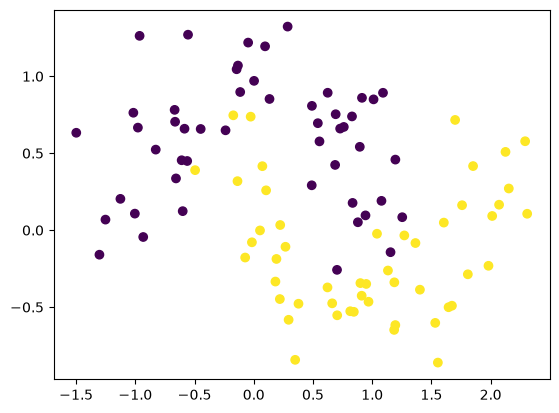

In [3]:
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', label='Train Data')
plt.show()

Make an ANN Model structure.

In [4]:
model1 = Sequential()
model1.add(Dense(128, input_dim=2, activation='relu'))
model1.add(Dense(128, activation='relu'))
model1.add(Dense(1, activation='sigmoid'))
model1.summary()

/home/hardik/Documents/learning_code/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1784394000.905853  617858 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

Train the model on the data.

In [5]:
adam = Adam(learning_rate=0.01)
model1.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])
history1 = model1.fit(X, y, epochs=2000, verbose=2, validation_split=0.2)

Epoch 1/2000
3/3 - 1s - 227ms/step - accuracy: 0.5625 - loss: 0.6399 - val_accuracy: 0.9000 - val_loss: 0.3929
Epoch 2/2000
3/3 - 0s - 19ms/step - accuracy: 0.8375 - loss: 0.4228 - val_accuracy: 0.9000 - val_loss: 0.2462
Epoch 3/2000
3/3 - 0s - 20ms/step - accuracy: 0.8625 - loss: 0.3767 - val_accuracy: 0.9000 - val_loss: 0.1908
Epoch 4/2000
3/3 - 0s - 21ms/step - accuracy: 0.8500 - loss: 0.3741 - val_accuracy: 0.9000 - val_loss: 0.2489
Epoch 5/2000
3/3 - 0s - 19ms/step - accuracy: 0.8500 - loss: 0.3882 - val_accuracy: 0.9000 - val_loss: 0.2897
Epoch 6/2000
3/3 - 0s - 18ms/step - accuracy: 0.8375 - loss: 0.3606 - val_accuracy: 0.9000 - val_loss: 0.2338
Epoch 7/2000
3/3 - 0s - 19ms/step - accuracy: 0.8375 - loss: 0.3567 - val_accuracy: 0.9000 - val_loss: 0.2079
Epoch 8/2000
3/3 - 0s - 20ms/step - accuracy: 0.8500 - loss: 0.3322 - val_accuracy: 0.9000 - val_loss: 0.2303
Epoch 9/2000
3/3 - 0s - 19ms/step - accuracy: 0.8625 - loss: 0.3213 - val_accuracy: 0.9000 - val_loss: 0.2296
Epoch 10/

Plot the data and decision boundary of the model.

<Axes: >

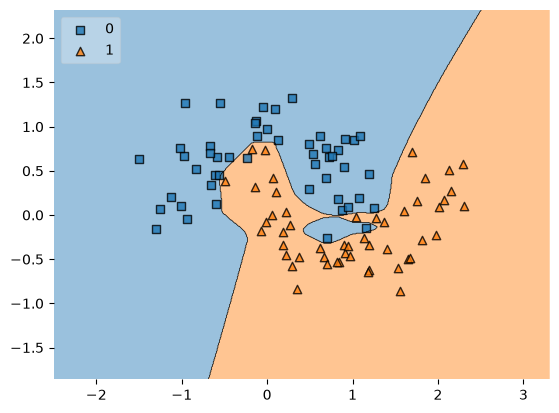

In [6]:
from mlxtend.plotting import plot_decision_regions
import numpy as np

class KerasClassifier:
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        pred = self.model.predict(X, verbose=0)
        return (pred > 0.5).astype(int).ravel()

clf = KerasClassifier(model1)
plot_decision_regions(X, y.astype(int), clf=clf, legend=2)

Plot the loss and validation loss.

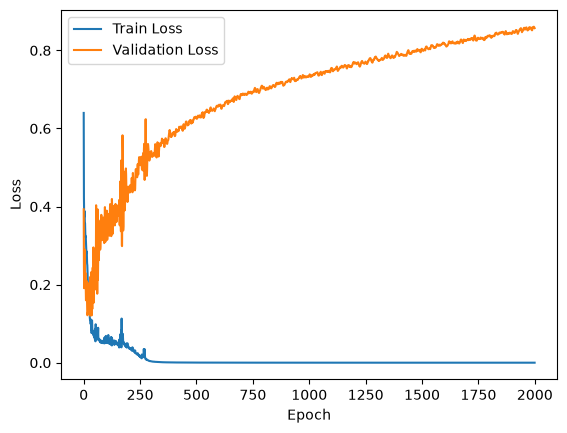

In [7]:
plt.plot(history1.history['loss'], label='Train Loss')
plt.plot(history1.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Make an ANN model structure with penalty term.

In [17]:
model2 = Sequential()

model2.add(Dense(128,input_dim=2, activation="relu",kernel_regularizer=keras.regularizers.l1(0.001)))
model2.add(Dense(128, activation="relu",kernel_regularizer=keras.regularizers.l1(0.001)))
model2.add(Dense(1,activation='sigmoid'))

model2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

Train the model on data.

In [18]:
adam = Adam(learning_rate=0.01)
model2.compile(loss='binary_crossentropy', optimizer=adam, metrics=['accuracy'])
history2 = model2.fit(X, y, epochs=2000, verbose=2, validation_split=0.2)

Epoch 1/2000


3/3 - 1s - 219ms/step - accuracy: 0.6500 - loss: 1.8322 - val_accuracy: 0.8500 - val_loss: 1.4401
Epoch 2/2000
3/3 - 0s - 19ms/step - accuracy: 0.8125 - loss: 1.3606 - val_accuracy: 0.9000 - val_loss: 1.0303
Epoch 3/2000
3/3 - 0s - 26ms/step - accuracy: 0.8250 - loss: 1.0760 - val_accuracy: 0.9000 - val_loss: 0.7753
Epoch 4/2000
3/3 - 0s - 20ms/step - accuracy: 0.8500 - loss: 0.8967 - val_accuracy: 0.9000 - val_loss: 0.6881
Epoch 5/2000
3/3 - 0s - 19ms/step - accuracy: 0.8500 - loss: 0.7858 - val_accuracy: 0.9000 - val_loss: 0.6205
Epoch 6/2000
3/3 - 0s - 21ms/step - accuracy: 0.8500 - loss: 0.7261 - val_accuracy: 0.9000 - val_loss: 0.5972
Epoch 7/2000
3/3 - 0s - 20ms/step - accuracy: 0.8375 - loss: 0.6938 - val_accuracy: 0.9000 - val_loss: 0.5886
Epoch 8/2000
3/3 - 0s - 20ms/step - accuracy: 0.8375 - loss: 0.6380 - val_accuracy: 0.9000 - val_loss: 0.5138
Epoch 9/2000
3/3 - 0s - 21ms/step - accuracy: 0.8250 - loss: 0.6090 - val_accuracy: 0.9000 - val_loss: 0.4889
Epoch 10/2000
3/3 - 0s

Plot decision boundary.

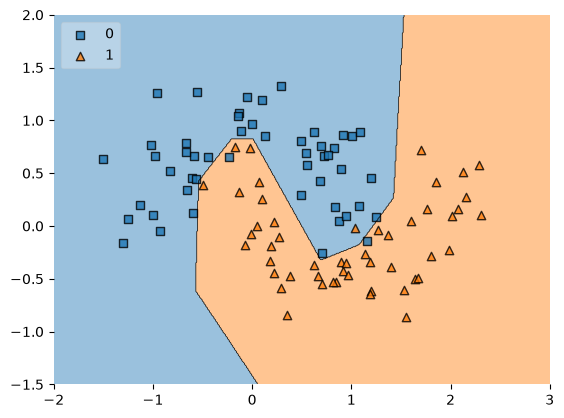

In [19]:
clf = KerasClassifier(model2)
plot_decision_regions(X, y.astype('int'), clf=clf, legend=2)
plt.xlim(-2,3)
plt.ylim(-1.5,2)
plt.show()

Plot loss and validation loss.

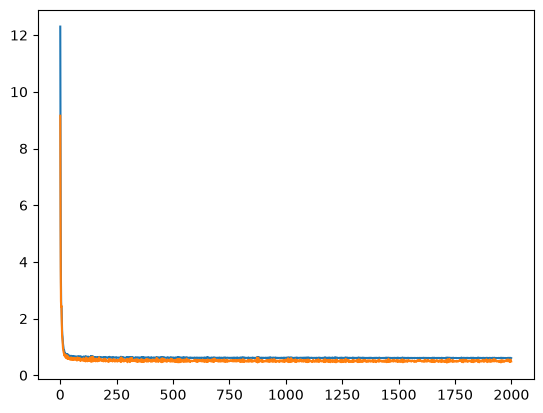

In [14]:
plt.plot(history2.history['loss'])
plt.plot(history2.history['val_loss'])

Box plots of the weights of both the models.

<Axes: >

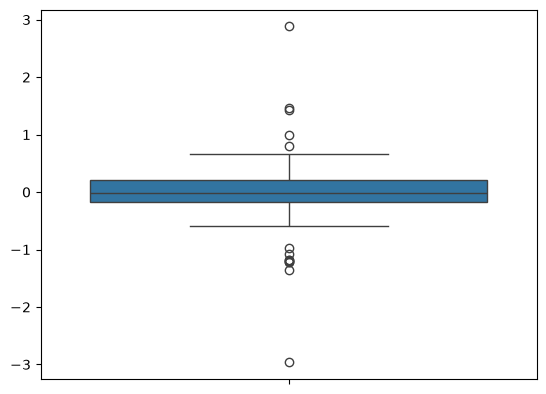

In [20]:
model1_weight_layer1 = model1.get_weights()[0].reshape(256)
model2_weight_layer1 = model2.get_weights()[0].reshape(256)
sns.boxplot(model1_weight_layer1)

<Axes: >

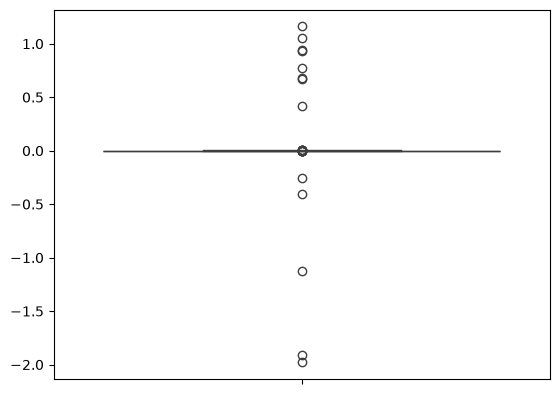

In [21]:
sns.boxplot(model2_weight_layer1)

In [22]:
model1_weight_layer1.min(), model2_weight_layer1.min()

(np.float32(-2.963555), np.float32(-1.9787856))

Plot the histogram of weight of both the models.

<Axes: ylabel='Count'>

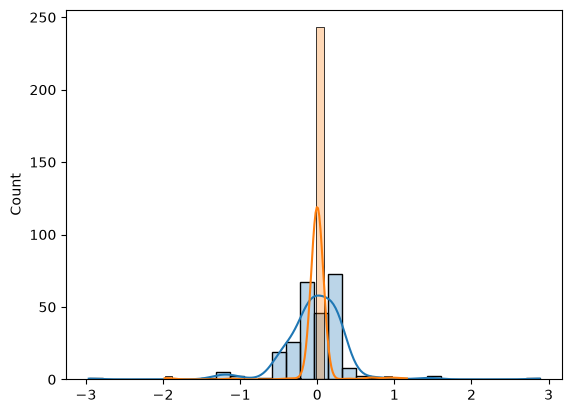

In [28]:
sns.histplot(model1_weight_layer1,kde=True,alpha=0.3, label='Model 1 Weights')
sns.histplot(model2_weight_layer1,kde=True,alpha=0.3, label='Model 2 Weights')

In [30]:
model1.get_weights()[0].reshape(256)

array([ 0.32693836, -0.38836658,  0.23272839, -0.4044645 ,  0.03346489,
        0.22432776, -0.35487017, -0.11256882, -0.40369162,  0.16902915,
        0.1968311 , -0.56407374,  0.22047941, -0.00972001, -0.5243319 ,
        0.2154413 , -0.5204679 , -0.08768623, -0.38051137,  0.2218708 ,
       -0.01649251, -0.06658053,  0.2370618 ,  0.0907018 ,  0.35422367,
       -0.5960201 , -0.19568527,  0.24316938,  0.24454884,  0.20918766,
        0.10896796, -0.4909736 ,  0.3281013 ,  0.1543859 , -0.507335  ,
        0.0285652 , -0.47934306,  0.14925657,  0.05006628, -0.43389645,
        0.03520441,  0.24041848,  0.20621672,  0.23853555,  0.23862989,
       -0.17809586,  0.25458267,  0.13583547, -0.02091611,  0.2708293 ,
       -0.47124782,  0.03684844, -0.08964349, -0.18923551, -0.2554524 ,
       -0.44161516,  0.29497245, -0.4673311 ,  0.2955687 ,  0.27404258,
        0.25232968,  0.16819891,  0.44129536,  0.21173592, -0.42788196,
       -0.08376016, -0.3156787 , -0.47610247, -0.09727491,  0.00